## Importing important libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import numpy as np

In [2]:
Data = pd.read_excel(r'\Data Science\_Projects\Doing\EU_Real_Estate_Project_Challenge\EU_Real_Estate_Dataset.xlsx')

In [3]:
Data.head()

,property_id,listing_date,property_type,listing_type,address,city,country,bedrooms,bathrooms,square_meters,...,latitude,longitude,last_sold_price_eur,parking_spots,gym,swimming_pool,elevator,furnishing_status,energy_rating,floor_number
0,PROP-00001,2021-06-06,Townhouse,Sale,Paseo de la Castellana 122,Madrid,Spain,2,2.0,94.0,...,40.444365,-3.705707,203111.0,2,No,No,Yes,Semi-Furnished,C,NaN
1,PROP-00002,2024-06-29,Apartment,Sale,Rue de la Loi 35,Brussels,Belgium,2,1.0,85.0,...,50.902379,4.276731,297896.0,0,No,No,No,Unfurnished,B,6.0
2,PROP-00003,2022-02-18,Townhouse,Sale,Aleje Jerozolimskie 170,Warsaw,Poland,3,2.0,111.0,...,52.278988,21.022699,103127.0,1,No,No,No,Semi-Furnished,G,NaN
3,PROP-00004,2020-11-02,Townhouse,Sale,Prinsengracht 191,Amsterdam,Netherlands,3,3.0,115.0,...,52.335220,4.831571,478928.0,1,Yes,Yes,No,Unfurnished,E,NaN
4,PROP-00005,2021-04-04,Apartment,Sale,Potsdamer Platz 14,Berlin,Germany,3,1.0,100.0,...,52.598500,13.326092,178311.0,1,No,No,Yes,Unfurnished,E,9.0


In [4]:
Data.columns

Index(['property_id', 'listing_date', 'property_type', 'listing_type',
       'address', 'city', 'country', 'bedrooms', 'bathrooms', 'square_meters',
       'year_built', 'sale_price_eur', 'monthly_rent_eur', 'price_per_sqm',
       'days_on_market', 'latitude', 'longitude', 'last_sold_price_eur',
       'parking_spots', 'gym', 'swimming_pool', 'elevator',
       'furnishing_status', 'energy_rating', 'floor_number'],
      dtype='object')

In [5]:
Data.dtypes

property_id                    object
listing_date           datetime64[ns]
property_type                  object
listing_type                   object
address                        object
city                           object
country                        object
bedrooms                        int64
bathrooms                     float64
square_meters                 float64
year_built                    float64
sale_price_eur                float64
monthly_rent_eur              float64
price_per_sqm                 float64
days_on_market                float64
latitude                      float64
longitude                     float64
last_sold_price_eur           float64
parking_spots                   int64
gym                            object
swimming_pool                  object
elevator                       object
furnishing_status              object
energy_rating                  object
floor_number                  float64
dtype: object

In [6]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   property_id          5000 non-null   object        
 1   listing_date         5000 non-null   datetime64[ns]
 2   property_type        5000 non-null   object        
 3   listing_type         5000 non-null   object        
 4   address              5000 non-null   object        
 5   city                 5000 non-null   object        
 6   country              5000 non-null   object        
 7   bedrooms             5000 non-null   int64         
 8   bathrooms            3225 non-null   float64       
 9   square_meters        4753 non-null   float64       
 10  year_built           4759 non-null   float64       
 11  sale_price_eur       2955 non-null   float64       
 12  monthly_rent_eur     2045 non-null   float64       
 13  price_per_sqm        4753 non-nul

In [7]:
Data.isnull().sum()

property_id               0
listing_date              0
property_type             0
listing_type              0
address                   0
city                      0
country                   0
bedrooms                  0
bathrooms              1775
square_meters           247
year_built              241
sale_price_eur         2045
monthly_rent_eur       2955
price_per_sqm           247
days_on_market          248
latitude                  0
longitude                 0
last_sold_price_eur     585
parking_spots             0
gym                       0
swimming_pool             0
elevator                  0
furnishing_status      1775
energy_rating             0
floor_number           1168
dtype: int64

#### Creating Date Id Column

In [8]:
Data['Date_Id'] = Data['listing_date'].dt.strftime('%y%m%d').astype(int)

In [9]:
Data['Date_Id']

0       210606
1       240629
2       220218
3       201102
4       210404
         ...  
4995    230523
4996    241019
4997    221002
4998    220623
4999    230913
Name: Date_Id, Length: 5000, dtype: int64

#### Creating Listing Id column

In [10]:
Data['Listing_ID'] = ('LST-' + Data['property_id'].astype(str) +'-' + Data['Date_Id'].astype(str) + '-' + Data['listing_type'].astype(str) )

In [11]:
Data['Listing_ID']

0         LST-PROP-00001-210606-Sale
1         LST-PROP-00002-240629-Sale
2         LST-PROP-00003-220218-Sale
3         LST-PROP-00004-201102-Sale
4         LST-PROP-00005-210404-Sale
                    ...             
4995    LST-PROP-04996-230523-Rental
4996      LST-PROP-04997-241019-Sale
4997    LST-PROP-04998-221002-Rental
4998      LST-PROP-04999-220623-Sale
4999    LST-PROP-05000-230913-Rental
Name: Listing_ID, Length: 5000, dtype: object

In [12]:
Data.columns

Index(['property_id', 'listing_date', 'property_type', 'listing_type',
       'address', 'city', 'country', 'bedrooms', 'bathrooms', 'square_meters',
       'year_built', 'sale_price_eur', 'monthly_rent_eur', 'price_per_sqm',
       'days_on_market', 'latitude', 'longitude', 'last_sold_price_eur',
       'parking_spots', 'gym', 'swimming_pool', 'elevator',
       'furnishing_status', 'energy_rating', 'floor_number', 'Date_Id',
       'Listing_ID'],
      dtype='object')

# Creating Fact Listings Table

In [13]:
Fact_Listings = Data[['Listing_ID', 'property_id', 'listing_date', 'listing_type', 'sale_price_eur', 'monthly_rent_eur', 'price_per_sqm', 'days_on_market', 'last_sold_price_eur']]

In [14]:
Fact_Listings.head()

,Listing_ID,property_id,listing_date,listing_type,sale_price_eur,monthly_rent_eur,price_per_sqm,days_on_market,last_sold_price_eur
0,LST-PROP-00001-210606-Sale,PROP-00001,2021-06-06,Sale,348394.0,NaN,3706.32,69.0,203111.0
1,LST-PROP-00002-240629-Sale,PROP-00002,2024-06-29,Sale,335807.0,NaN,3950.67,119.0,297896.0
2,LST-PROP-00003-220218-Sale,PROP-00003,2022-02-18,Sale,141235.0,NaN,1272.39,354.0,103127.0
3,LST-PROP-00004-201102-Sale,PROP-00004,2020-11-02,Sale,1132226.0,NaN,9845.44,140.0,478928.0
4,LST-PROP-00005-210404-Sale,PROP-00005,2021-04-04,Sale,286081.0,NaN,2860.81,NaN,178311.0


## Creating Dimensional Property Table

In [15]:
Dim_Property = Data[['property_id', 'property_type', 'address', 'city', 'country', 'year_built', 'square_meters', 'latitude', 'longitude']]

In [16]:
Dim_Property.head()

,property_id,property_type,address,city,country,year_built,square_meters,latitude,longitude
0,PROP-00001,Townhouse,Paseo de la Castellana 122,Madrid,Spain,1998.0,94.0,40.444365,-3.705707
1,PROP-00002,Apartment,Rue de la Loi 35,Brussels,Belgium,1978.0,85.0,50.902379,4.276731
2,PROP-00003,Townhouse,Aleje Jerozolimskie 170,Warsaw,Poland,1976.0,111.0,52.278988,21.022699
3,PROP-00004,Townhouse,Prinsengracht 191,Amsterdam,Netherlands,1946.0,115.0,52.335220,4.831571
4,PROP-00005,Apartment,Potsdamer Platz 14,Berlin,Germany,1930.0,100.0,52.598500,13.326092


# Creating Dimensional Features Tables

In [17]:
Dim_Features = Data[['property_id', 'bedrooms', 'bathrooms', 'parking_spots', 'gym', 'swimming_pool', 'elevator', 'furnishing_status', 'energy_rating', 'floor_number']]

In [18]:
Dim_Features.head()

,property_id,bedrooms,bathrooms,parking_spots,gym,swimming_pool,elevator,furnishing_status,energy_rating,floor_number
0,PROP-00001,2,2.0,2,No,No,Yes,Semi-Furnished,C,NaN
1,PROP-00002,2,1.0,0,No,No,No,Unfurnished,B,6.0
2,PROP-00003,3,2.0,1,No,No,No,Semi-Furnished,G,NaN
3,PROP-00004,3,3.0,1,Yes,Yes,No,Unfurnished,E,NaN
4,PROP-00005,3,1.0,1,No,No,Yes,Unfurnished,E,9.0


# Creating Dimensional Date

In [19]:
Dim_Date = Data[['Date_Id', 'listing_date']]

In [20]:
Dim_Date.head()

,Date_Id,listing_date
0,210606,2021-06-06
1,240629,2024-06-29
2,220218,2022-02-18
3,201102,2020-11-02
4,210404,2021-04-04


#### Renaming listing_date to Date

In [21]:
Dim_Date = Dim_Date.rename(columns={'listing_date':'Date'})

In [22]:
Dim_Date.head()

,Date_Id,Date
0,210606,2021-06-06
1,240629,2024-06-29
2,220218,2022-02-18
3,201102,2020-11-02
4,210404,2021-04-04


In [23]:
max(Dim_Date['Date'])

Timestamp('2024-12-30 00:00:00')

In [24]:
min(Dim_Date['Date'])

Timestamp('2020-01-01 00:00:00')

* # Data Cleaning & Exploratory Data Analysis (EDA)

* Fact Listings table

In [25]:
Fact_Listings.head()

,Listing_ID,property_id,listing_date,listing_type,sale_price_eur,monthly_rent_eur,price_per_sqm,days_on_market,last_sold_price_eur
0,LST-PROP-00001-210606-Sale,PROP-00001,2021-06-06,Sale,348394.0,NaN,3706.32,69.0,203111.0
1,LST-PROP-00002-240629-Sale,PROP-00002,2024-06-29,Sale,335807.0,NaN,3950.67,119.0,297896.0
2,LST-PROP-00003-220218-Sale,PROP-00003,2022-02-18,Sale,141235.0,NaN,1272.39,354.0,103127.0
3,LST-PROP-00004-201102-Sale,PROP-00004,2020-11-02,Sale,1132226.0,NaN,9845.44,140.0,478928.0
4,LST-PROP-00005-210404-Sale,PROP-00005,2021-04-04,Sale,286081.0,NaN,2860.81,NaN,178311.0


In [26]:
Fact_Listings.dtypes

Listing_ID                     object
property_id                    object
listing_date           datetime64[ns]
listing_type                   object
sale_price_eur                float64
monthly_rent_eur              float64
price_per_sqm                 float64
days_on_market                float64
last_sold_price_eur           float64
dtype: object

In [27]:
Fact_Listings = Fact_Listings.copy()

In [28]:
Fact_Listings['days_on_market'] = Fact_Listings['days_on_market'].astype('Int64')

In [29]:
Fact_Listings.describe()

,listing_date,sale_price_eur,monthly_rent_eur,price_per_sqm,days_on_market,last_sold_price_eur
count,5000,2.955000e+03,2045.000000,4753.000000,4752.0,4.415000e+03
mean,2022-06-25 22:04:30.720000,1.052201e+06,3660.186797,3152.317808,171.780513,6.990353e+05
min,2020-01-01 00:00:00,5.000000e+04,400.000000,42.450000,1.0,2.333200e+04
25%,2021-03-02 18:00:00,3.676300e+05,1450.000000,229.720000,81.0,2.447040e+05
50%,2022-07-05 00:00:00,6.463630e+05,2432.000000,2753.100000,166.0,4.364820e+05
75%,2023-10-02 00:00:00,1.228540e+06,4317.000000,5004.080000,260.0,8.333955e+05
max,2024-12-30 00:00:00,1.328730e+07,47411.000000,19756.210000,365.0,8.511737e+06
std,NaN,1.268308e+06,3937.368099,3187.631039,104.870569,7.962859e+05


In [30]:
Fact_Listings.columns

Index(['Listing_ID', 'property_id', 'listing_date', 'listing_type',
       'sale_price_eur', 'monthly_rent_eur', 'price_per_sqm', 'days_on_market',
       'last_sold_price_eur'],
      dtype='object')

In [31]:
print(f'Total dublicated rows in listing_id = {sum(Fact_Listings['Listing_ID'].duplicated())}')

Total dublicated rows in listing_id = 0


In [32]:
len(Fact_Listings)

5000

In [33]:
Fact_Listings = Fact_Listings.drop_duplicates()

In [34]:
len(Fact_Listings)

5000

In [35]:
Fact_Listings.isna().sum()

Listing_ID                0
property_id               0
listing_date              0
listing_type              0
sale_price_eur         2045
monthly_rent_eur       2955
price_per_sqm           247
days_on_market          248
last_sold_price_eur     585
dtype: int64

In [36]:
Fact_Listings[Fact_Listings['listing_type'] == 'Rental']

,Listing_ID,property_id,listing_date,listing_type,sale_price_eur,monthly_rent_eur,price_per_sqm,days_on_market,last_sold_price_eur
5,LST-PROP-00006-231216-Rental,PROP-00006,2023-12-16,Rental,NaN,1913.0,255.07,86,500108.0
8,LST-PROP-00009-220717-Rental,PROP-00009,2022-07-17,Rental,NaN,4693.0,347.63,291,1204803.0
9,LST-PROP-00010-200625-Rental,PROP-00010,2020-06-25,Rental,NaN,1389.0,216.47,186,247438.0
11,LST-PROP-00012-210907-Rental,PROP-00012,2021-09-07,Rental,NaN,1103.0,161.41,250,277915.0
14,LST-PROP-00015-210510-Rental,PROP-00015,2021-05-10,Rental,NaN,8038.0,326.97,151,NaN
...,...,...,...,...,...,...,...,...,...
4990,LST-PROP-04991-210105-Rental,PROP-04991,2021-01-05,Rental,NaN,2567.0,119.40,305,1252462.0
4994,LST-PROP-04995-200219-Rental,PROP-04995,2020-02-19,Rental,NaN,4594.0,144.31,350,2448011.0
4995,LST-PROP-04996-230523-Rental,PROP-04996,2023-05-23,Rental,NaN,8321.0,NaN,85,260718.0
4997,LST-PROP-04998-221002-Rental,PROP-04998,2022-10-02,Rental,NaN,1166.0,137.18,203,332107.0


In [37]:

Fact_Listings['listing_type']

0         Sale
1         Sale
2         Sale
3         Sale
4         Sale
         ...  
4995    Rental
4996      Sale
4997    Rental
4998      Sale
4999    Rental
Name: listing_type, Length: 5000, dtype: object

In [38]:
Fact_Listings['listing_type'].value_counts()

listing_type
Sale      2955
Rental    2045
Name: count, dtype: int64

In [39]:
Fact_Listings[Fact_Listings['listing_type'] == 'Sale']

,Listing_ID,property_id,listing_date,listing_type,sale_price_eur,monthly_rent_eur,price_per_sqm,days_on_market,last_sold_price_eur
0,LST-PROP-00001-210606-Sale,PROP-00001,2021-06-06,Sale,348394.0,NaN,3706.32,69,203111.0
1,LST-PROP-00002-240629-Sale,PROP-00002,2024-06-29,Sale,335807.0,NaN,3950.67,119,297896.0
2,LST-PROP-00003-220218-Sale,PROP-00003,2022-02-18,Sale,141235.0,NaN,1272.39,354,103127.0
3,LST-PROP-00004-201102-Sale,PROP-00004,2020-11-02,Sale,1132226.0,NaN,9845.44,140,478928.0
4,LST-PROP-00005-210404-Sale,PROP-00005,2021-04-04,Sale,286081.0,NaN,2860.81,<NA>,178311.0
...,...,...,...,...,...,...,...,...,...
4991,LST-PROP-04992-210317-Sale,PROP-04992,2021-03-17,Sale,1281582.0,NaN,9934.74,<NA>,735320.0
4992,LST-PROP-04993-210604-Sale,PROP-04993,2021-06-04,Sale,360179.0,NaN,3531.17,195,278187.0
4993,LST-PROP-04994-240812-Sale,PROP-04994,2024-08-12,Sale,281323.0,NaN,2164.02,180,195425.0
4996,LST-PROP-04997-241019-Sale,PROP-04997,2024-10-19,Sale,304339.0,NaN,4830.78,<NA>,252049.0


In [40]:
Fact_Listings[Fact_Listings['price_per_sqm'].isnull()]

,Listing_ID,property_id,listing_date,listing_type,sale_price_eur,monthly_rent_eur,price_per_sqm,days_on_market,last_sold_price_eur
48,LST-PROP-00049-200812-Rental,PROP-00049,2020-08-12,Rental,NaN,2993.0,NaN,156,261044.0
109,LST-PROP-00110-200425-Rental,PROP-00110,2020-04-25,Rental,NaN,11317.0,NaN,284,207551.0
113,LST-PROP-00114-240601-Rental,PROP-00114,2024-06-01,Rental,NaN,1786.0,NaN,<NA>,229297.0
115,LST-PROP-00116-200812-Sale,PROP-00116,2020-08-12,Sale,1115013.0,NaN,NaN,200,605459.0
116,LST-PROP-00117-200822-Rental,PROP-00117,2020-08-22,Rental,NaN,5820.0,NaN,<NA>,247174.0
...,...,...,...,...,...,...,...,...,...
4928,LST-PROP-04929-201202-Rental,PROP-04929,2020-12-02,Rental,NaN,742.0,NaN,230,202403.0
4956,LST-PROP-04957-240122-Sale,PROP-04957,2024-01-22,Sale,1976535.0,NaN,NaN,68,923816.0
4963,LST-PROP-04964-230528-Sale,PROP-04964,2023-05-28,Sale,153144.0,NaN,NaN,93,122780.0
4978,LST-PROP-04979-240311-Sale,PROP-04979,2024-03-11,Sale,493657.0,NaN,NaN,253,367587.0


In [41]:
Fact_Listings.columns

Index(['Listing_ID', 'property_id', 'listing_date', 'listing_type',
       'sale_price_eur', 'monthly_rent_eur', 'price_per_sqm', 'days_on_market',
       'last_sold_price_eur'],
      dtype='object')

In [42]:
print(f"Total renting listing is {len(Fact_Listings[Fact_Listings['listing_type'] == 'Rental'])}")
print(f"Total sale listing is {len(Fact_Listings[Fact_Listings['listing_type'] == 'Sale'])}")

Total renting listing is 2045
Total sale listing is 2955


In [43]:
Fact_Listings.groupby(by=['listing_type']).agg(
    AVG_Month_rent_eur=('monthly_rent_eur','mean'),
    AVG_Days_in_market=('days_on_market', 'mean')
    )

,AVG_Month_rent_eur,AVG_Days_in_market
listing_type,,
Rental,3660.186797,173.548486
Sale,NaN,170.551195


In [96]:
Fact_Listings['Year'] = Fact_Listings['listing_date'].dt.year.astype('int')

In [101]:
Fact_Listings['Year']

0       2021
1       2024
2       2022
3       2020
4       2021
        ... 
4995    2023
4996    2024
4997    2022
4998    2022
4999    2023
Name: Year, Length: 5000, dtype: int64

In [102]:
sale = Fact_Listings[Fact_Listings['listing_type'] == 'Sale'].groupby('Year').agg(avg_price_per_sqm=('price_per_sqm','mean'))

In [103]:
sale

,avg_price_per_sqm
Year,
2020,5187.214080
2021,5241.258321
2022,4957.886057
2023,5309.698265
2024,5225.156268


In [104]:
sale.index

Index([2020, 2021, 2022, 2023, 2024], dtype='int64', name='Year')

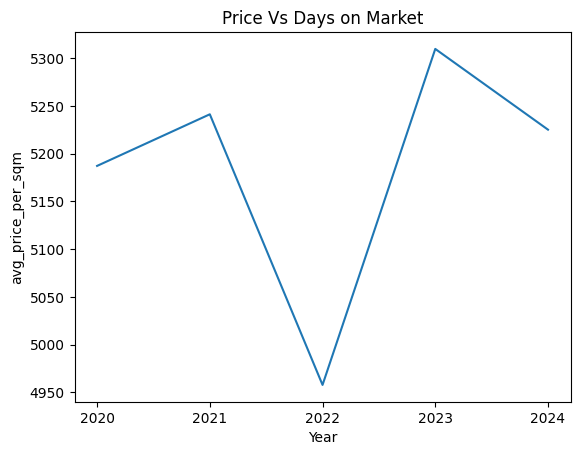

In [113]:
import matplotlib.ticker as mticker
sns.lineplot(x=sale.index, y=sale['avg_price_per_sqm'])
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.title('Price Vs Days on Market')
plt.show()

In [149]:
years = Fact_Listings['Year'].unique

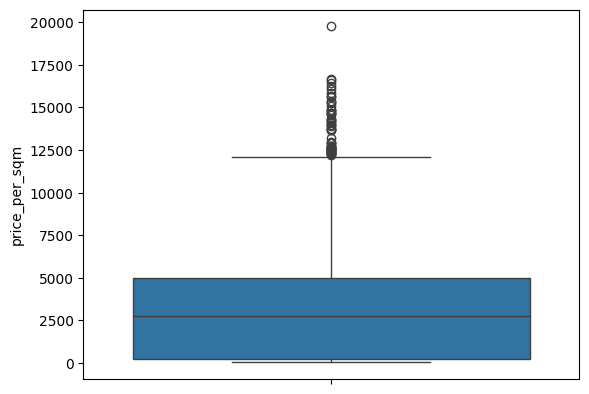

In [153]:
sns.boxplot(data=Fact_Listings, y='price_per_sqm')
plt.show()

In [114]:
rental = Fact_Listings[Fact_Listings['listing_type'] == 'Rental'].groupby('Year').agg(AVG_Monthly_rent=('monthly_rent_eur', 'mean'))

In [115]:
rental

,AVG_Monthly_rent
Year,
2020,3624.754545
2021,3422.468354
2022,4257.318560
2023,3509.665188
2024,3564.231156


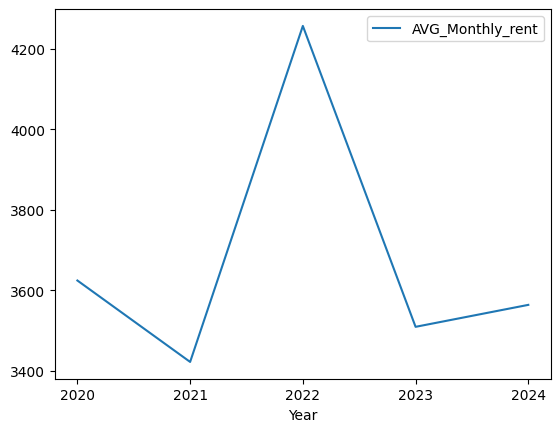

In [129]:
sns.lineplot(rental)
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.show()

* Dim_Property Table

In [44]:
Dim_Property.head(5)

,property_id,property_type,address,city,country,year_built,square_meters,latitude,longitude
0,PROP-00001,Townhouse,Paseo de la Castellana 122,Madrid,Spain,1998.0,94.0,40.444365,-3.705707
1,PROP-00002,Apartment,Rue de la Loi 35,Brussels,Belgium,1978.0,85.0,50.902379,4.276731
2,PROP-00003,Townhouse,Aleje Jerozolimskie 170,Warsaw,Poland,1976.0,111.0,52.278988,21.022699
3,PROP-00004,Townhouse,Prinsengracht 191,Amsterdam,Netherlands,1946.0,115.0,52.335220,4.831571
4,PROP-00005,Apartment,Potsdamer Platz 14,Berlin,Germany,1930.0,100.0,52.598500,13.326092


In [45]:
Dim_Property.dtypes

property_id       object
property_type     object
address           object
city              object
country           object
year_built       float64
square_meters    float64
latitude         float64
longitude        float64
dtype: object

In [46]:
Dim_Property=Dim_Property.copy()

In [47]:
Dim_Property['year_built'] = Dim_Property['year_built'].astype('Int64')

In [48]:
Dim_Property.dtypes

property_id       object
property_type     object
address           object
city              object
country           object
year_built         Int64
square_meters    float64
latitude         float64
longitude        float64
dtype: object

In [49]:
Dim_Property['property_type'].value_counts()

property_type
Apartment    2057
Villa         679
Office        620
Retail        541
Townhouse     489
Mixed-Use     368
Warehouse     246
Name: count, dtype: int64

In [50]:
Dim_Property.groupby(['property_type']).\
    agg(AVG_square_meters=('square_meters', 'mean')).\
        sort_values(by='AVG_square_meters', ascending=False)

,AVG_square_meters
property_type,
Mixed-Use,304.562857
Warehouse,302.939394
Office,288.011925
Retail,286.563601
Villa,143.633333
Apartment,118.477144
Townhouse,116.869379


In [51]:
Dim_Property.describe()

,year_built,square_meters,latitude,longitude
count,4759.0,4753.000000,5000.000000,5000.000000
mean,1970.586468,183.489165,47.620772,7.353262
std,26.086061,139.040119,4.931976,8.599695
min,1901.0,30.000000,38.638119,-9.219034
25%,1952.0,96.000000,41.906160,2.342365
50%,1974.0,140.000000,48.880074,4.961903
75%,1991.0,216.000000,52.292246,13.481300
max,2021.0,1000.000000,52.599875,21.091743


In [52]:
Dim_Property.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_id    5000 non-null   object 
 1   property_type  5000 non-null   object 
 2   address        5000 non-null   object 
 3   city           5000 non-null   object 
 4   country        5000 non-null   object 
 5   year_built     4759 non-null   Int64  
 6   square_meters  4753 non-null   float64
 7   latitude       5000 non-null   float64
 8   longitude      5000 non-null   float64
dtypes: Int64(1), float64(3), object(5)
memory usage: 356.6+ KB


In [53]:
Dim_Property.isna().sum()

property_id        0
property_type      0
address            0
city               0
country            0
year_built       241
square_meters    247
latitude           0
longitude          0
dtype: int64

In [54]:
Dim_Property.shape

(5000, 9)

In [55]:
Dim_Property = Dim_Property.drop_duplicates(subset=['property_id'])

In [56]:
Dim_Property.shape

(5000, 9)

* Dim Feature Table

In [57]:
Dim_Features.head()

,property_id,bedrooms,bathrooms,parking_spots,gym,swimming_pool,elevator,furnishing_status,energy_rating,floor_number
0,PROP-00001,2,2.0,2,No,No,Yes,Semi-Furnished,C,NaN
1,PROP-00002,2,1.0,0,No,No,No,Unfurnished,B,6.0
2,PROP-00003,3,2.0,1,No,No,No,Semi-Furnished,G,NaN
3,PROP-00004,3,3.0,1,Yes,Yes,No,Unfurnished,E,NaN
4,PROP-00005,3,1.0,1,No,No,Yes,Unfurnished,E,9.0


In [58]:
Dim_Features.dtypes

property_id           object
bedrooms               int64
bathrooms            float64
parking_spots          int64
gym                   object
swimming_pool         object
elevator              object
furnishing_status     object
energy_rating         object
floor_number         float64
dtype: object

In [59]:
Dim_Features = Dim_Features.copy()

In [60]:
Dim_Features['bathrooms'] = Dim_Features['bathrooms'].astype('Int64')
Dim_Features['floor_number'] = Dim_Features['floor_number'].astype('Int64')

In [61]:
Dim_Features.dtypes

property_id          object
bedrooms              int64
bathrooms             Int64
parking_spots         int64
gym                  object
swimming_pool        object
elevator             object
furnishing_status    object
energy_rating        object
floor_number          Int64
dtype: object

In [62]:
sum(Dim_Features.duplicated(subset=['property_id']))

0

* Dim Date Table

In [63]:
Dim_Date.head()

,Date_Id,Date
0,210606,2021-06-06
1,240629,2024-06-29
2,220218,2022-02-18
3,201102,2020-11-02
4,210404,2021-04-04


In [64]:
Dim_Date.dtypes

Date_Id             int64
Date       datetime64[ns]
dtype: object

In [65]:
Dim_Date['Month_name'] = Dim_Date['Date'].dt.month_name()
Dim_Date['Day_name'] = Dim_Date['Date'].dt.day_name()
Dim_Date['Year'] = Dim_Date['Date'].dt.year
Dim_Date['Quarter'] = Dim_Date['Date'].dt.quarter

In [66]:
Dim_Date.head()

,Date_Id,Date,Month_name,Day_name,Year,Quarter
0,210606,2021-06-06,June,Sunday,2021,2
1,240629,2024-06-29,June,Saturday,2024,2
2,220218,2022-02-18,February,Friday,2022,1
3,201102,2020-11-02,November,Monday,2020,4
4,210404,2021-04-04,April,Sunday,2021,2


# Datawarehousing 

In [160]:
file_path='/Data Science/_Projects/Doing/EU_Real_Estate_Project_Challenge/Datawarehouse/EU_Real_Estate.xlsx'
with pd.ExcelWriter(file_path, engine='openpyxl') as writer:
    Fact_Listings.to_excel(writer, sheet_name='Fact_Listings', index=False)
    Dim_Property.to_excel(writer, sheet_name='Dim_Property', index=False)
    Dim_Features.to_excel(writer, sheet_name='Dim_Feature', index=False)
    Dim_Date.to_excel(writer, sheet_name='Dim_Date', index=False)